In [50]:
#import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [51]:
#load the dataset

df=pd.read_csv(r"C:\Users\LENOVO\Desktop\data analytics\netflix_titles.csv")
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [52]:
#info about dataset(basic)

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [53]:
#check the missing values

df.isnull().sum()


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [54]:
#handle the missing values

df['country'] = df['country'].fillna("Unknown")
df['director'] = df['director'].fillna("Not Available")
df['cast'] = df['cast'].fillna("Not Available")
df['rating'] = df['rating'].fillna("Unknown")
df['duration'] = df['duration'].fillna("Unknown")


In [55]:
#convert date_added to datetime format

df['date_added']=pd.to_datetime(df['date_added'], errors='coerce')


In [56]:
#extract year and month from date_added

df['year']=df['date_added'].dt.year
df['month']=df['date_added'].dt.month
df['month_name']=df['date_added'].dt.month_name()
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year,month,month_name
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0,September
1,s2,TV Show,Blood & Water,Not Available,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0,September
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0,September
3,s4,TV Show,Jailbirds New Orleans,Not Available,Not Available,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0,September
4,s5,TV Show,Kota Factory,Not Available,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0,September


In [57]:
#remove duplicates
df.drop_duplicates(inplace=True)
df.duplicated().sum()


np.int64(0)

In [ ]:
#split genres(handling multiple genres)

df['genres']=df['listed_in'].str.split(',')
df_genres=df.explode('genres')
df_genres['genre']=df_genres['genres'].str.strip()
df_genres.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year,month,month_name,genres,genre
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0,September,Documentaries,Documentaries
1,s2,TV Show,Blood & Water,Not Available,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0,September,International TV Shows,International TV Shows
1,s2,TV Show,Blood & Water,Not Available,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0,September,TV Dramas,TV Dramas
1,s2,TV Show,Blood & Water,Not Available,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0,September,TV Mysteries,TV Mysteries
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0,September,Crime TV Shows,Crime TV Shows


In [ ]:
#split country(handling multiple countries)

df['country_split']=df['country'].str.split(',')
df_country = df.explode('country_split')
df_country['country_split'] = df_country['country_split'].str.strip()
df_country.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year,month,month_name,genres,country_split
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0,September,[Documentaries],United States
1,s2,TV Show,Blood & Water,Not Available,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0,September,"[International TV Shows, TV Dramas, TV Myste...",South Africa
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0,September,"[Crime TV Shows, International TV Shows, TV ...",Unknown
3,s4,TV Show,Jailbirds New Orleans,Not Available,Not Available,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0,September,"[Docuseries, Reality TV]",Unknown
4,s5,TV Show,Kota Factory,Not Available,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0,September,"[International TV Shows, Romantic TV Shows, ...",India


In [ ]:
# Separate Movie and TV show (for duration analysis)

movies = df[df['type'] == 'Movie'].copy()
tv_shows = df[df['type'] == 'TV Show'].copy()

# Clean movie duration (minutes)
# Movies
movies['duration'] = movies['duration'].str.replace(' min','')
movies['duration'] = pd.to_numeric(movies['duration'], errors='coerce')

# Clean TV show duration (seasons)
tv_shows['duration'] = tv_shows['duration'].str.replace(' Seasons','').str.replace(' Season','')
tv_shows['duration'] = pd.to_numeric(tv_shows['duration'], errors='coerce')


In [90]:
# Convert detailed rating labels into broader audience categories for easier analysis

rating_map = {
    'TV-MA': 'Adults', 'R': 'Adults', 'NC-17': 'Adults',
    'PG-13': 'Teens', 'TV-14': 'Teens',
    'PG': 'Kids', 'TV-PG': 'Kids',
    'G': 'Kids', 'TV-Y': 'Kids', 'TV-Y7': 'Kids'
}

df['rating_group'] = df['rating'].map(rating_map).fillna('General')
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year,month,month_name,genres,country_split,rating_group
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0,September,[Documentaries],[United States],Teens
1,s2,TV Show,Blood & Water,Not Available,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0,September,"[International TV Shows, TV Dramas, TV Myste...",[South Africa],Adults
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0,September,"[Crime TV Shows, International TV Shows, TV ...",[Unknown],Adults
3,s4,TV Show,Jailbirds New Orleans,Not Available,Not Available,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0,September,"[Docuseries, Reality TV]",[Unknown],Adults
4,s5,TV Show,Kota Factory,Not Available,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0,September,"[International TV Shows, Romantic TV Shows, ...",[India],Adults


**EDA** 

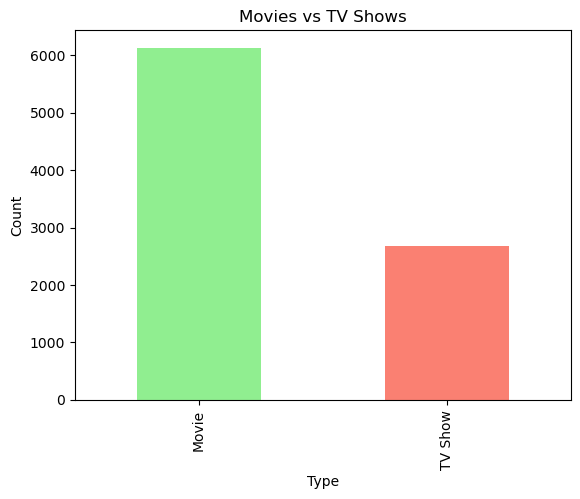

In [111]:
#Movies vs TV Shows

df['type'].value_counts().plot(kind='bar', color=['lightgreen', 'salmon'])
plt.title('Movies vs TV Shows')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()


**remark** : Movies dominate Netflix content compared to TV Shows.

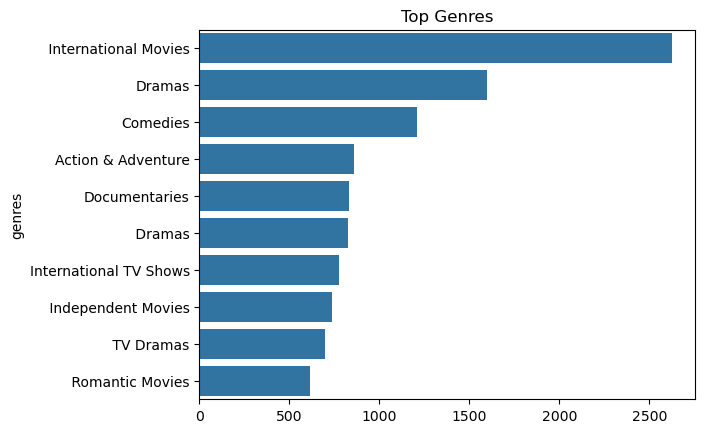

In [109]:
#Top genres on Netflix

top_genres=df_genres['genres'].value_counts().head(10)

sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title('Top Genres')
plt.show()


**Insight**: Drama and International Movies are most common.

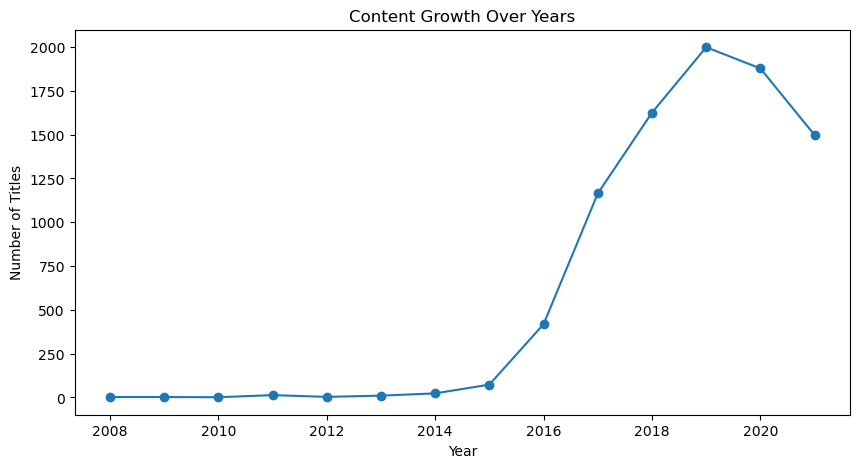

In [68]:
#Yearly Trend

yearly=df['year'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(yearly.index, yearly.values, marker='o')
plt.title('Content Growth Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()


**Insight**:Netflix content grew rapidly after 2015, reaching its peak in recent years.

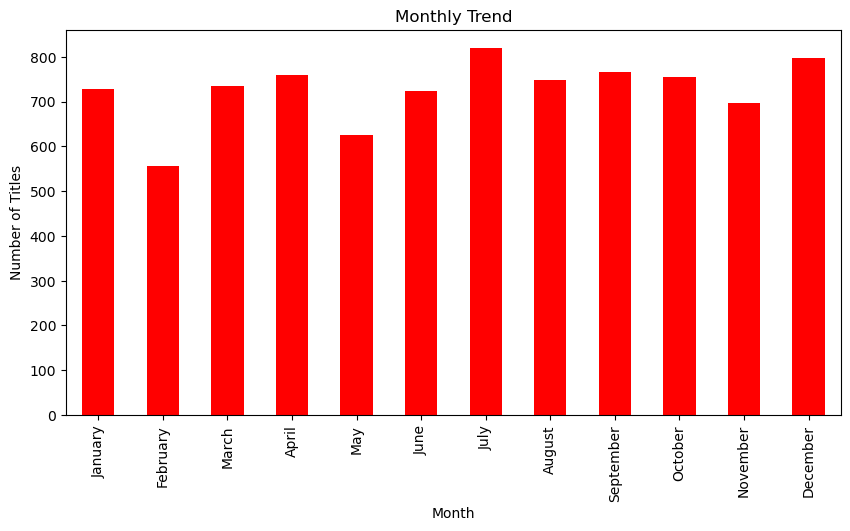

In [107]:
#Monthly Trend

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly = df['month_name'].value_counts().reindex(month_order)

plt.figure(figsize=(10,5))
monthly.plot(kind='bar', color='red')
plt.xticks(rotation=90)
plt.title("Monthly Trend")
plt.xlabel("Month")
plt.ylabel("Number of Titles")
plt.show()


**Result**: Netflix releases more content during mid-year and holiday seasons, with July and December showing peak activity.

Highest releases: 257 in July, 2021.0


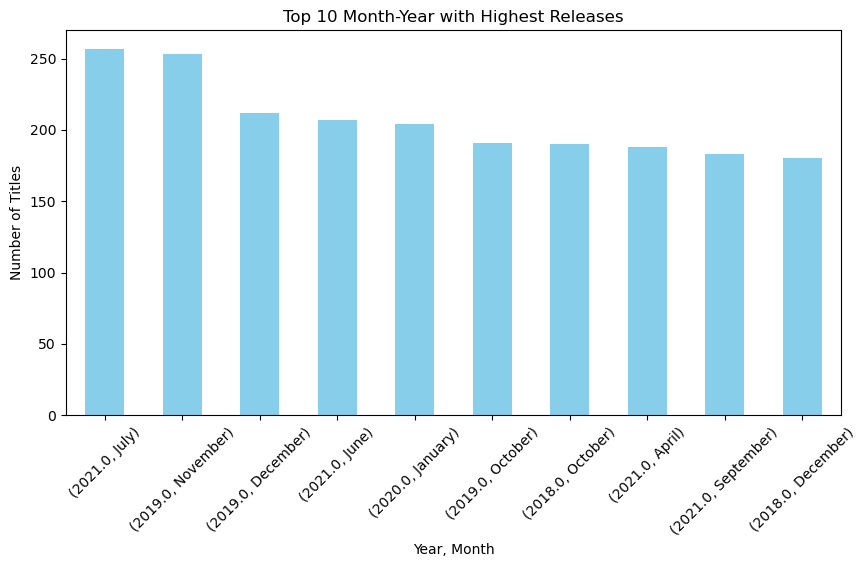

In [105]:
#Monthly-Yearly Analysis (top 10 month-year commbinations)

counts = df.groupby(['year', 'month_name']).size()
max_value = counts.max()
year, month = counts.idxmax()
print(f"Highest releases: {max_value} in {month}, {year}")


top10 = counts.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top10.plot(kind='bar', color='skyblue')

plt.title("Top 10 Month-Year with Highest Releases")
plt.xlabel("Year, Month")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()


Netflix added the most content in **recent years**(after 2017), especially around months like **July** and **December**. 

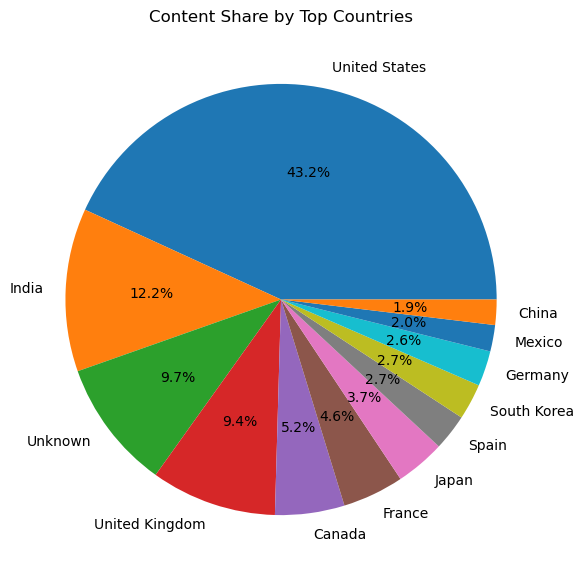

In [ ]:
#top countries producing content

top_countries = df_country['country_split'].value_counts().head(12)

plt.figure(figsize=(7,7))
plt.pie(top_countries.values, labels=top_countries.index, autopct='%1.1f%%')
plt.title("Content Share by Top Countries")
plt.show()


**insight** : The *United States* contributes the largest share of Netflix content.

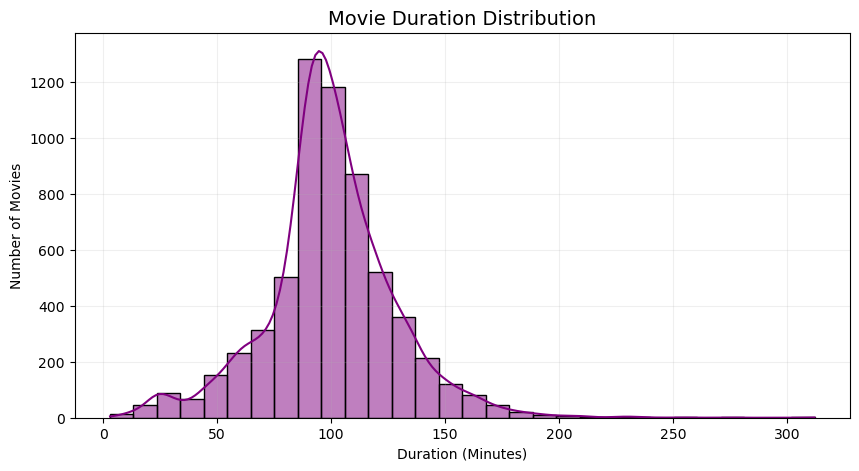

In [104]:
#Movie Duration Analysis

plt.figure(figsize=(10,5))

sns.histplot(movies['duration'], bins=30, kde=True, color='purple')
# Titles and labels
plt.title("Movie Duration Distribution", fontsize=14)
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.grid(alpha=0.2)

plt.show()


Insight: Most movies are around *90–120* minutes.

In [88]:
#analyzing movie duration highest to lowest

# Find movie with maximum duration
longest_movie = movies.loc[movies['duration'].idxmax()]

print(f"Longest Movie- {longest_movie['title']} ({longest_movie['duration']} minutes)")

# Find movie with minimum duration
shortest_movie = movies.loc[movies['duration'].idxmin()]

print(f"Shortest Movie- {shortest_movie['title']} ({shortest_movie['duration']} minutes)")


Longest Movie- Black Mirror: Bandersnatch (312.0 minutes)
Shortest Movie- Silent (3.0 minutes)


Insight: Some movies like **‘Black Mirror: Bandersnatch’** and **'Silent'** appear as outliers with unusually high & low durations compared to other movies

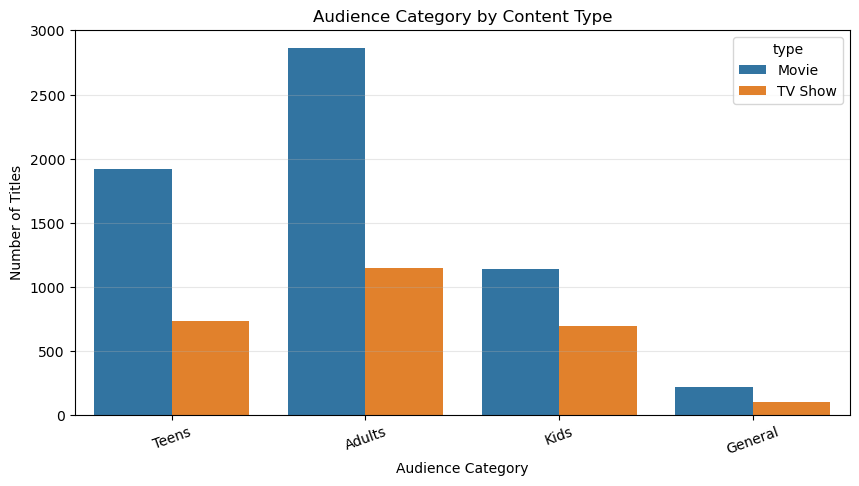

In [99]:
# Audience Category Distribution(by content type)

plt.figure(figsize=(10,5))

sns.countplot(data=df, x='rating_group', hue='type')

plt.title("Audience Category by Content Type")
plt.xlabel("Audience Category")
plt.ylabel("Number of Titles")

plt.xticks(rotation=20)
plt.grid(axis='y', alpha=0.3)

plt.show()


Insight: Most stuff on Netflix is for *adults*, and movies are more than TV shows in every category.